DATA ANALYSIS

Checking the distribution of data

In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd
    
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objs as go
colors = px.colors.sequential.Plasma_r
import matplotlib.pyplot as plt


DATA CLEANING

In [2]:
path_data  = '../../data/'
df = pd.read_csv(path_data+"CVD_cleaned.csv")

(General_Health                  0
 Checkup                         0
 Exercise                        0
 Heart_Disease                   0
 Skin_Cancer                     0
 Other_Cancer                    0
 Depression                      0
 Diabetes                        0
 Arthritis                       0
 Sex                             0
 Age_Category                    0
 Height_(cm)                     0
 Weight_(kg)                     0
 BMI                             0
 Smoking_History                 0
 Alcohol_Consumption             0
 Fruit_Consumption               0
 Green_Vegetables_Consumption    0
 FriedPotato_Consumption         0
 dtype: int64,
 <Axes: >)

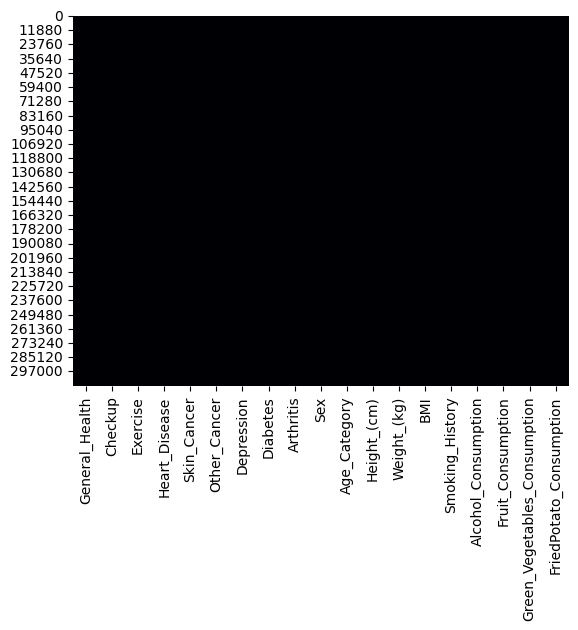

In [3]:
df.isna().sum(),sns.heatmap(df.isna(),cmap='magma', cbar=False)

In [4]:
lst = [ 'Height_(cm)', 'Weight_(kg)', 'BMI','Alcohol_Consumption', 'Fruit_Consumption','Green_Vegetables_Consumption', 'FriedPotato_Consumption']
for i in lst:
  print("Minimium value of ",i,"is",df[i].min())
  print("Mean value of ",i,"is",df[i].mean())
  print("Maximum value of ",i,"is",df[i].max())
  print("-"*75)

Minimium value of  Height_(cm) is 91.0
Mean value of  Height_(cm) is 170.61524862880196
Maximum value of  Height_(cm) is 241.0
---------------------------------------------------------------------------
Minimium value of  Weight_(kg) is 24.95
Mean value of  Weight_(kg) is 83.58865454227563
Maximum value of  Weight_(kg) is 293.02
---------------------------------------------------------------------------
Minimium value of  BMI is 12.02
Mean value of  BMI is 28.62621053960772
Maximum value of  BMI is 99.33
---------------------------------------------------------------------------
Minimium value of  Alcohol_Consumption is 0.0
Mean value of  Alcohol_Consumption is 5.096365920467276
Maximum value of  Alcohol_Consumption is 30.0
---------------------------------------------------------------------------
Minimium value of  Fruit_Consumption is 0.0
Mean value of  Fruit_Consumption is 29.835200450698387
Maximum value of  Fruit_Consumption is 120.0
----------------------------------------------

Tanto del diagrama de caja como del código se desprende claramente que existen valores atípicos. Al comparar el valor medio y el valor máximo, el valor máximo está muy lejos del valor medio. La verificación cruzada doble se implementa porque este conjunto de datos está relacionado con la salud; los valores extremos pueden ser posibles debido a condiciones médicas extremas. Al mismo tiempo, existe otra posibilidad de que las personas respondan palabras falsas o suposiciones en el sistema de revisión basado en llamadas telefónicas. Es imposible garantizar al 100 por ciento que las respuestas sean exactas. De todos modos, en el siguiente paso se eliminan los valores atípicos identificados.

In [5]:
 # Counting the ouliers in each feature
lst = [ 'Height_(cm)', 'Weight_(kg)', 'BMI','Alcohol_Consumption', 'Fruit_Consumption','Green_Vegetables_Consumption', 'FriedPotato_Consumption']
for i in lst:
  Q1 = df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR = Q3-Q1
  lower = Q1-3*IQR
  upper = Q3+3*IQR
  ot_cnt = ((df[i]<lower) | (df[i]>upper)).sum()
  ot_percentage = np.divide(np.multiply(ot_cnt,100),308854)
  ot_round = np.round(ot_percentage,decimals=0)
  print(i," : ",ot_cnt," : ",ot_round,"%")

Height_(cm)  :  82  :  0.0 %
Weight_(kg)  :  684  :  0.0 %
BMI  :  1279  :  0.0 %
Alcohol_Consumption  :  21221  :  7.0 %
Fruit_Consumption  :  19940  :  6.0 %
Green_Vegetables_Consumption  :  2889  :  1.0 %
FriedPotato_Consumption  :  11254  :  4.0 %


In [6]:
lst = [ 'Height_(cm)', 'Weight_(kg)', 'BMI','Alcohol_Consumption', 'Fruit_Consumption','Green_Vegetables_Consumption', 'FriedPotato_Consumption']
for i in lst:
  Q1 = df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR = Q3-Q1
  lower = Q1-3*IQR
  upper = Q3+3*IQR
  df= df[(df[i]>=lower) &(df[i]<=upper)|(df[i].isnull())]
df.reset_index(drop=True, inplace=True)
df.shape

(256341, 19)

In [117]:
# Convertimos a categóricas si no lo están ya
categorical_cols = ['General_Health', 'Checkup', 'Exercise', 'Sex', 'Age_Category', 'Smoking_History']
for col in categorical_cols:
    df[col] = df[col].astype('category')


In [116]:
df.columns

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History',
       'Alcohol_Consumption', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'FriedPotato_Consumption'],
      dtype='object')

In [122]:
print(df['Heart_Disease'].unique())
print(df['Heart_Disease'].dtype)

# Ejemplo si los valores son 'Yes' y 'No'
df['Heart_Disease'] = df['Heart_Disease'].map({'Yes': 1, 'No': 0})

df['Heart_Disease'] = df['Heart_Disease'].astype(int)

formula = 'Heart_Disease ~ Age_Category + Sex + BMI + Smoking_History + Exercise + Alcohol_Consumption'
modelo_logit = smf.logit(formula=formula, data=df).fit()
print(modelo_logit.summary())


['No' 'Yes']
object
Optimization terminated successfully.
         Current function value: 0.237038
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:          Heart_Disease   No. Observations:               256341
Model:                          Logit   Df Residuals:                   256323
Method:                           MLE   Df Model:                           17
Date:                Sun, 06 Apr 2025   Pseudo R-squ.:                  0.1553
Time:                        20:25:33   Log-Likelihood:                -60763.
converged:                       True   LL-Null:                       -71932.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -6.3781      0.130    -49.047      0.

In [121]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

# Convertir fórmula a matriz de diseño
y, X = dmatrices(formula, data=df, return_type='dataframe')

# Calcular VIF
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)


                  Variable        VIF
0                Intercept  43.036148
1        Age_Category[T.1]   1.738050
2        Age_Category[T.2]   1.867193
3        Age_Category[T.3]   1.957784
4        Age_Category[T.4]   2.013123
5        Age_Category[T.5]   1.996897
6        Age_Category[T.6]   2.165849
7        Age_Category[T.7]   2.289136
8        Age_Category[T.8]   2.455846
9        Age_Category[T.9]   2.479660
10      Age_Category[T.10]   2.384000
11      Age_Category[T.11]   1.946773
12      Age_Category[T.12]   2.019082
13             Sex[T.Male]   1.025041
14  Smoking_History[T.Yes]   1.045210
15         Exercise[T.Yes]   1.069753
16                     BMI   1.066659
17     Alcohol_Consumption   1.050279


array([[<Axes: title={'center': 'Height_(cm)'}>,
        <Axes: title={'center': 'Weight_(kg)'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Alcohol_Consumption'}>,
        <Axes: title={'center': 'Fruit_Consumption'}>,
        <Axes: title={'center': 'Green_Vegetables_Consumption'}>],
       [<Axes: title={'center': 'FriedPotato_Consumption'}>, <Axes: >,
        <Axes: >]], dtype=object)

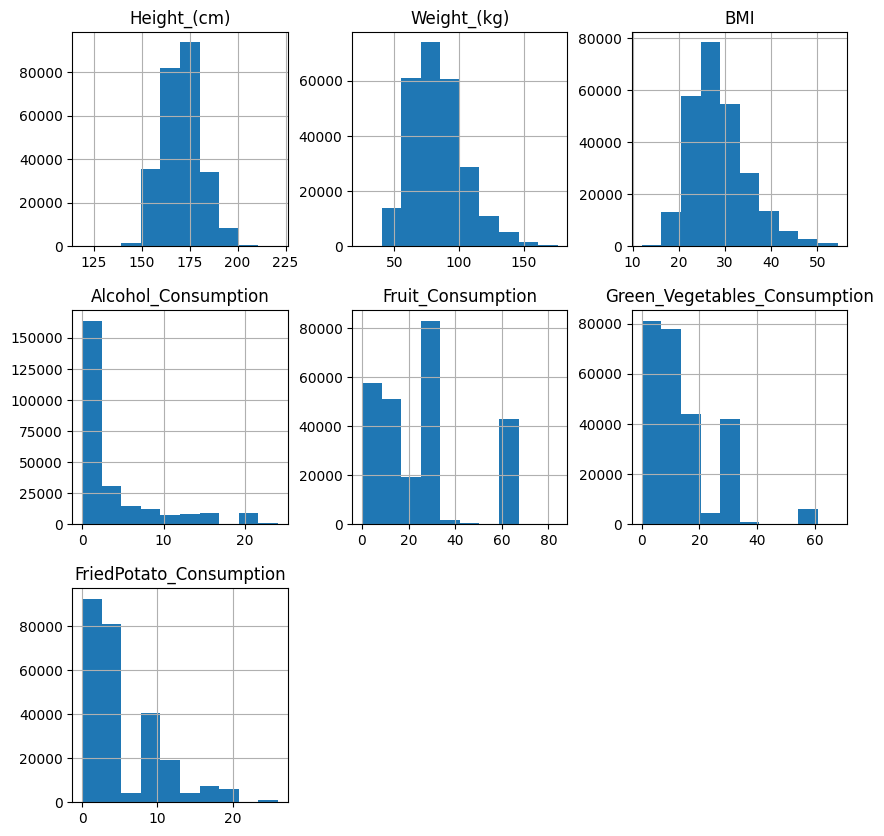

In [7]:
df.hist(figsize=(10,10))

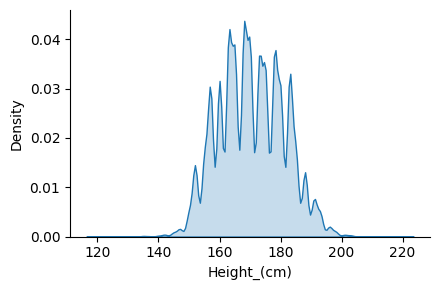

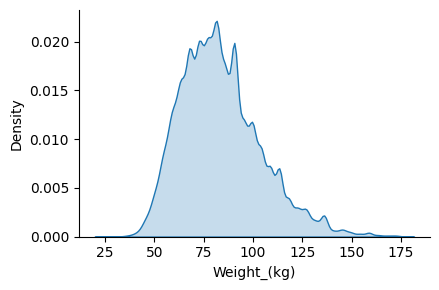

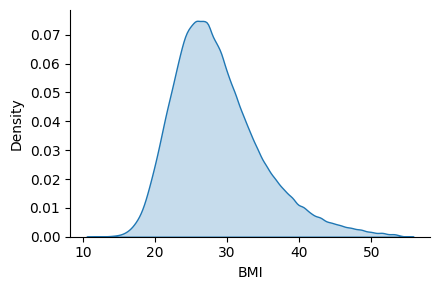

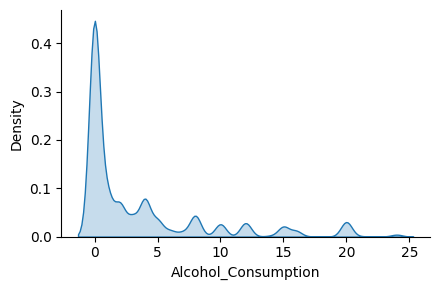

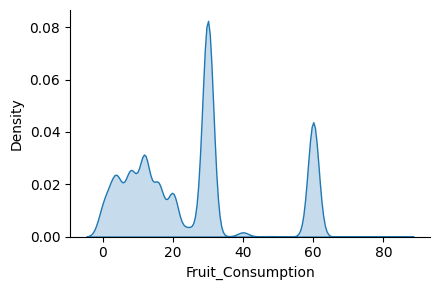

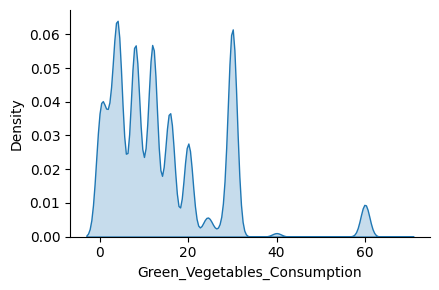

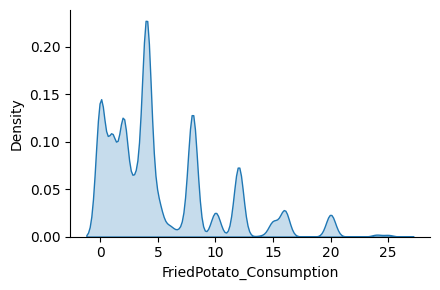

In [8]:
numerical_attributes = ['Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']
for i in numerical_attributes:
    g = sns.FacetGrid(df,height=3,aspect=1.5)
    g = g.map(sns.kdeplot,i,shade=True)

Observaciones:

<Axes: xlabel='General_Health', ylabel='count'>

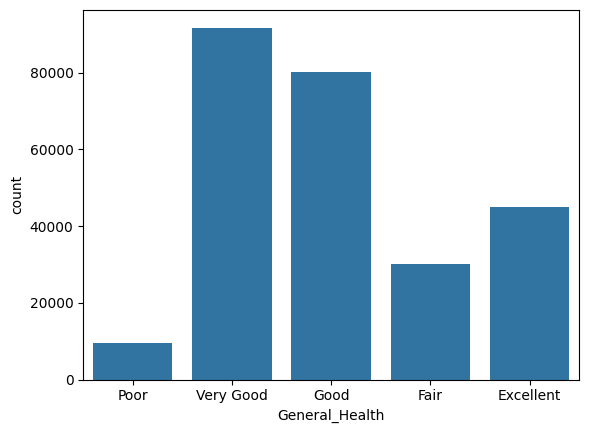

In [9]:
sns.countplot(data=df,x="General_Health")

In [10]:
General_Health_sub =["Poor","Very Good","Good","Fair","Excellent"]
for i in General_Health_sub:
  count = df.loc[df["General_Health"]==i] [["General_Health"]].count()
  average=(count*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  Poor General_Health    3
dtype: int64
Percentage of  Very Good General_Health    35
dtype: int64
Percentage of  Good General_Health    31
dtype: int64
Percentage of  Fair General_Health    11
dtype: int64
Percentage of  Excellent General_Health    17
dtype: int64


very good>good>excellent>fair>poor: 

Percentage of "Poor General_Health": 3%\
Percentage of "Very Good General_Health": 35%\
Percentage of "Good General_Health": 30%\
Percentage of "Fair General_Health": 11%\
Percentage of "Excellent General_Health": 18%

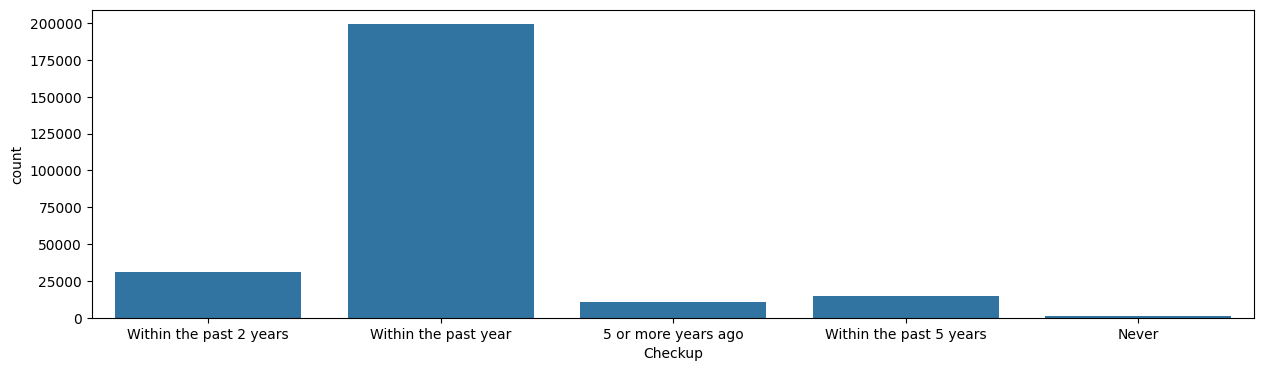

In [11]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Checkup")
plt.show()

In [12]:
Checkup_sub =["Within the past 2 years","Within the past year","5 or more years ago","Within the past 5 years","Never"]
for i in Checkup_sub:
  countc = df.loc[df["Checkup"]==i] [["Checkup"]].count()
  average=(countc*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  Within the past 2 years Checkup    12
dtype: int64
Percentage of  Within the past year Checkup    77
dtype: int64
Percentage of  5 or more years ago Checkup    4
dtype: int64
Percentage of  Within the past 5 years Checkup    5
dtype: int64
Percentage of  Never Checkup    0
dtype: int64


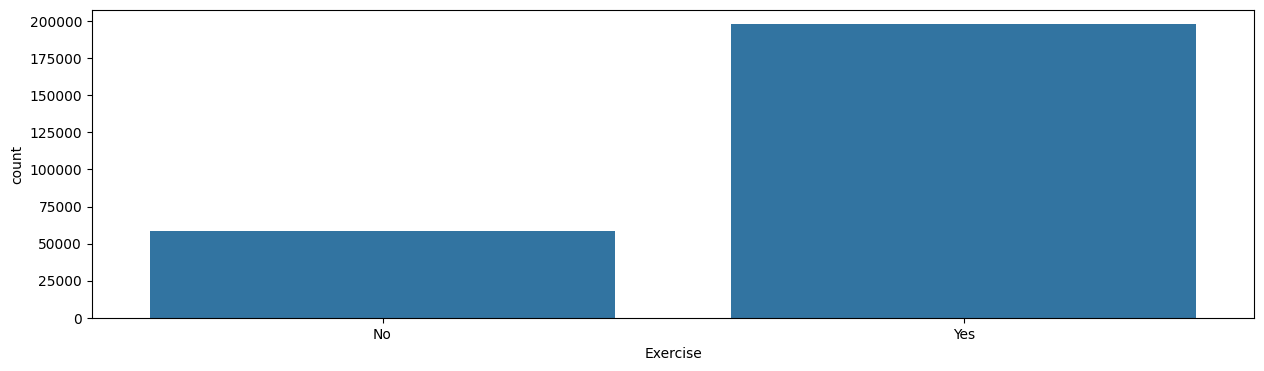

In [13]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Exercise")
plt.show()

In [14]:
Exercise_sub =["No","Yes"]
for i in Exercise_sub:
  countc = df.loc[df["Exercise"]==i] [["Exercise"]].count()
  average=(countc*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  No Exercise    22
dtype: int64
Percentage of  Yes Exercise    77
dtype: int64


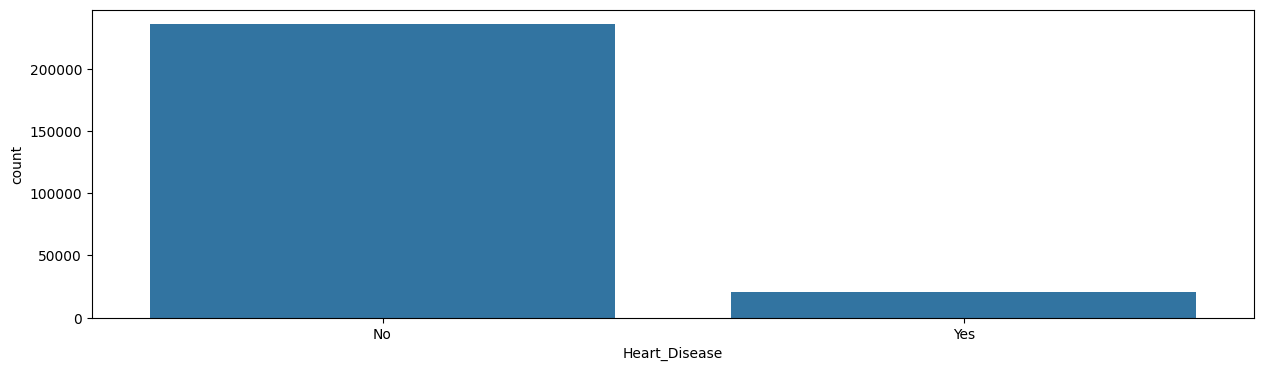

In [15]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Heart_Disease")
plt.show()

In [16]:
Heart_Disease_sub =["No","Yes"]
for i in Heart_Disease_sub:
  countc = df.loc[df["Heart_Disease"]==i] [["Heart_Disease"]].count()
  average=(countc*100)//len(df)
  print("Percentage of ",i,average)
  print(countc)

Percentage of  No Heart_Disease    91
dtype: int64
Heart_Disease    235640
dtype: int64
Percentage of  Yes Heart_Disease    8
dtype: int64
Heart_Disease    20701
dtype: int64


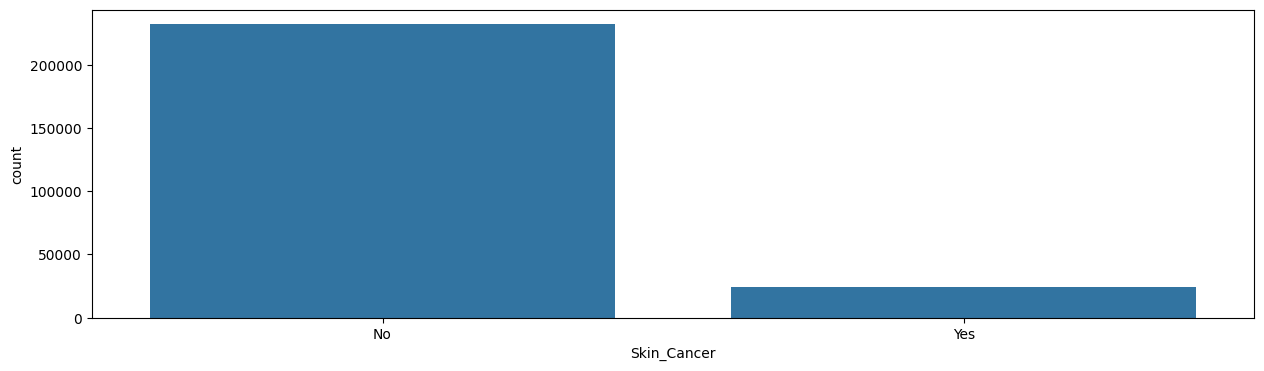

In [17]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Skin_Cancer")
plt.show()

In [18]:
Skin_Cancer_sub =["No","Yes"]
for i in Skin_Cancer_sub:
  countc = df.loc[df["Skin_Cancer"]==i] [["Skin_Cancer"]].count()
  average=(countc*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  No Skin_Cancer    90
dtype: int64
Percentage of  Yes Skin_Cancer    9
dtype: int64


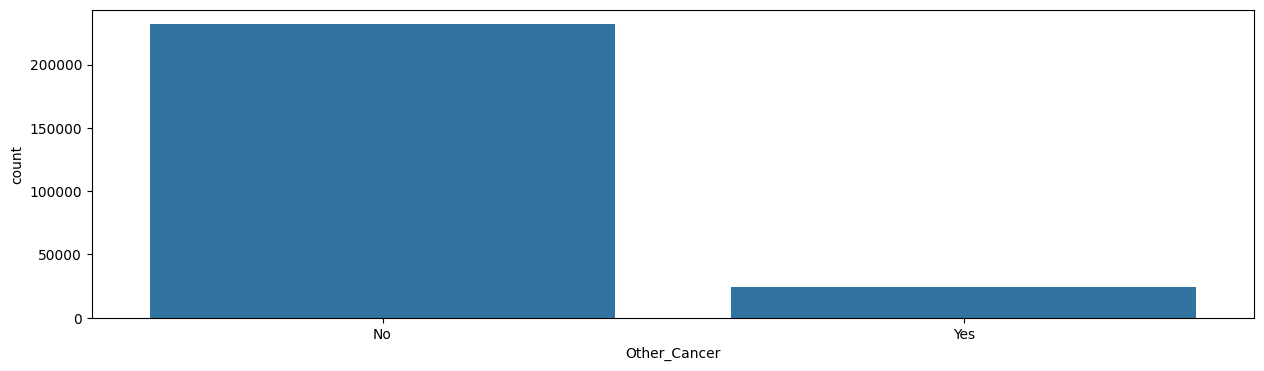

In [19]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Other_Cancer")
plt.show()

In [20]:
Other_Cancer_sub=["No","Yes"]
for i in Other_Cancer_sub:
  countO = df.loc[df["Other_Cancer"]==i] [["Other_Cancer"]].count()
  average=(countO*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  No Other_Cancer    90
dtype: int64
Percentage of  Yes Other_Cancer    9
dtype: int64


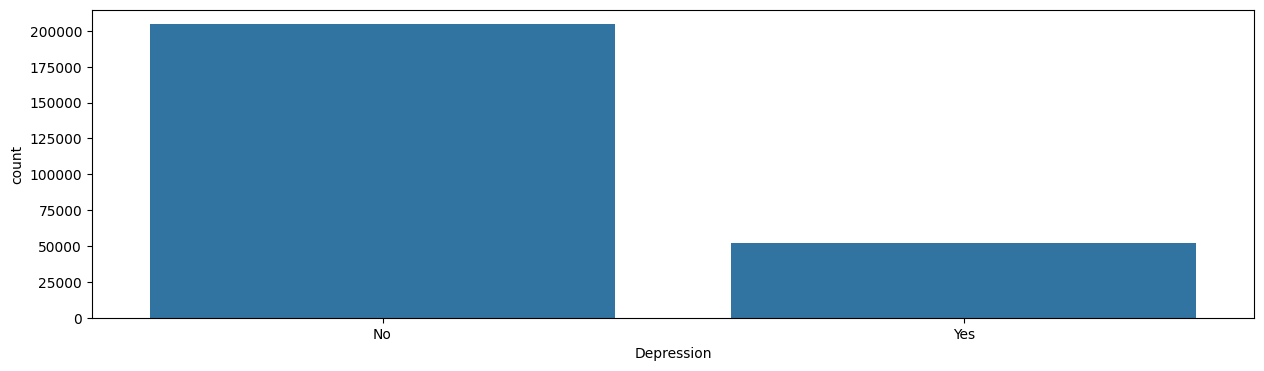

In [21]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Depression")
plt.show()

In [22]:
Depression_sub=["No","Yes"]
for i in Depression_sub:
  countd = df.loc[df["Depression"]==i] [["Depression"]].count()
  average=(countd*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  No Depression    79
dtype: int64
Percentage of  Yes Depression    20
dtype: int64


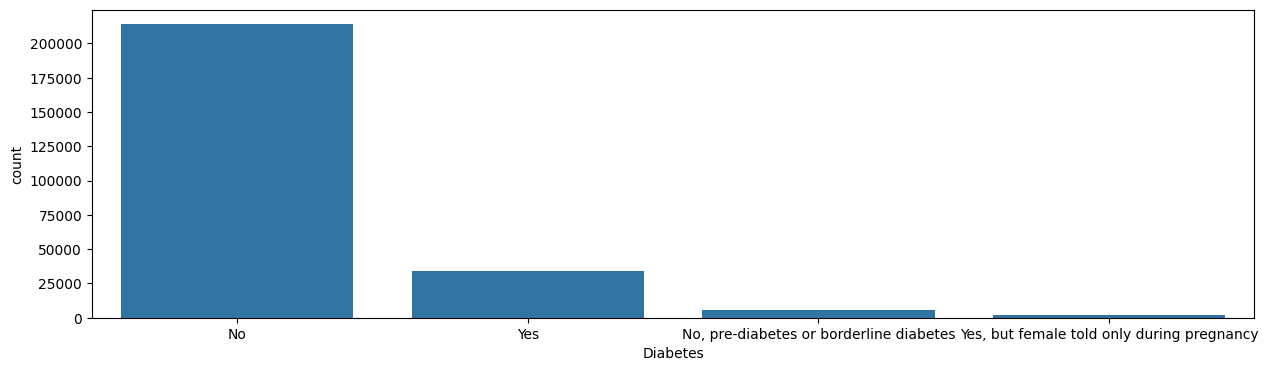

In [23]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Diabetes")
plt.show()

In [24]:
Diabetes_sub=["No","Yes"]
for i in Diabetes_sub:
  countd = df.loc[df["Diabetes"]==i] [["Diabetes"]].count()
  average=(countd*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  No Diabetes    83
dtype: int64
Percentage of  Yes Diabetes    13
dtype: int64


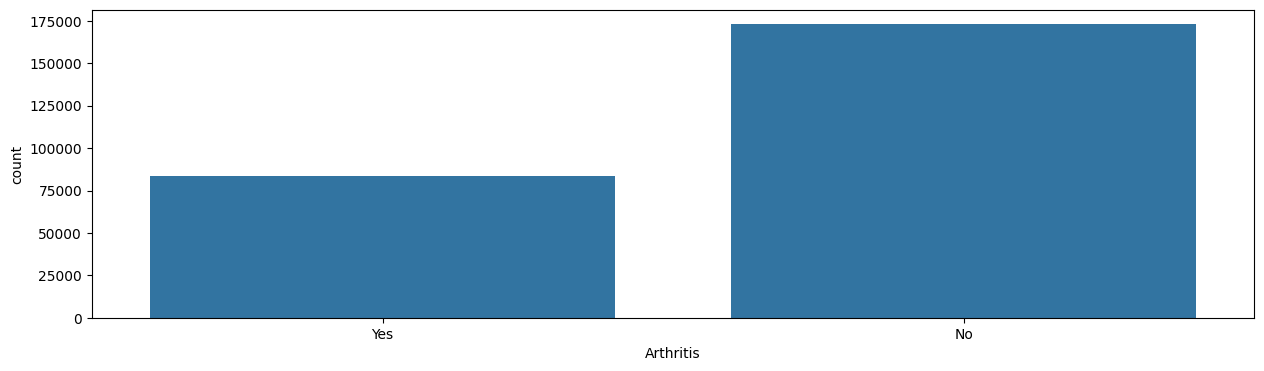

In [25]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Arthritis")
plt.show()

In [26]:
Arthritis_sub=["No","Yes"]
for i in Arthritis_sub:
  countd = df.loc[df["Arthritis"]==i] [["Arthritis"]].count()
  average=(countd*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  No Arthritis    67
dtype: int64
Percentage of  Yes Arthritis    32
dtype: int64


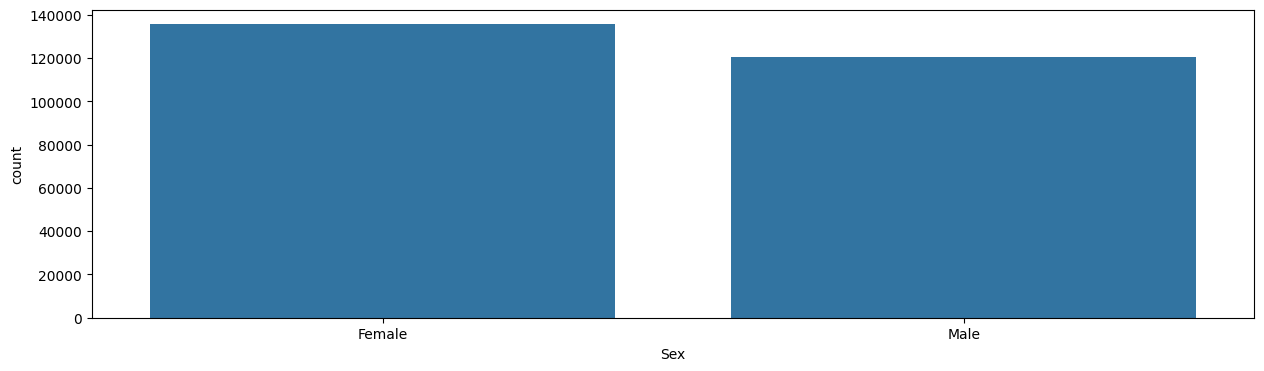

In [27]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Sex")
plt.show()

In [28]:
Sex_sub=["Female","Male"]
for i in Sex_sub:
  counts = df.loc[df["Sex"]==i] [["Sex"]].count()
  average=(counts*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  Female Sex    52
dtype: int64
Percentage of  Male Sex    47
dtype: int64


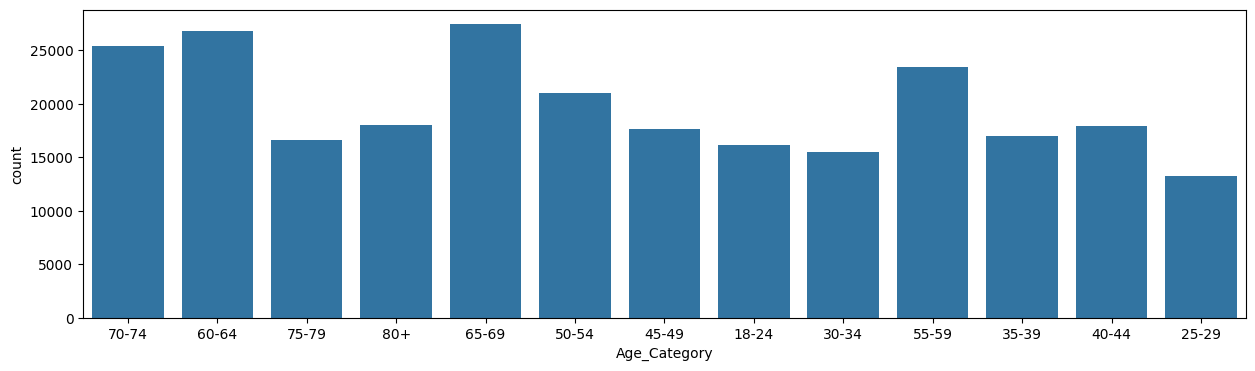

In [29]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Age_Category")
plt.show()

In [30]:
df["Age_Category"].unique()

array(['70-74', '60-64', '75-79', '80+', '65-69', '50-54', '45-49',
       '18-24', '30-34', '55-59', '35-39', '40-44', '25-29'], dtype=object)

In [31]:
Age_Category_sub=['70-74', '60-64', '75-79', '80+', '65-69', '50-54', '45-49','18-24', '30-34', '55-59', '35-39', '40-44', '25-29']
for i in Age_Category_sub:
  countd = df.loc[df["Age_Category"]==i] [["Age_Category"]].count()
  average=(countd*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  70-74 Age_Category    9
dtype: int64
Percentage of  60-64 Age_Category    10
dtype: int64
Percentage of  75-79 Age_Category    6
dtype: int64
Percentage of  80+ Age_Category    7
dtype: int64
Percentage of  65-69 Age_Category    10
dtype: int64
Percentage of  50-54 Age_Category    8
dtype: int64
Percentage of  45-49 Age_Category    6
dtype: int64
Percentage of  18-24 Age_Category    6
dtype: int64
Percentage of  30-34 Age_Category    6
dtype: int64
Percentage of  55-59 Age_Category    9
dtype: int64
Percentage of  35-39 Age_Category    6
dtype: int64
Percentage of  40-44 Age_Category    7
dtype: int64
Percentage of  25-29 Age_Category    5
dtype: int64


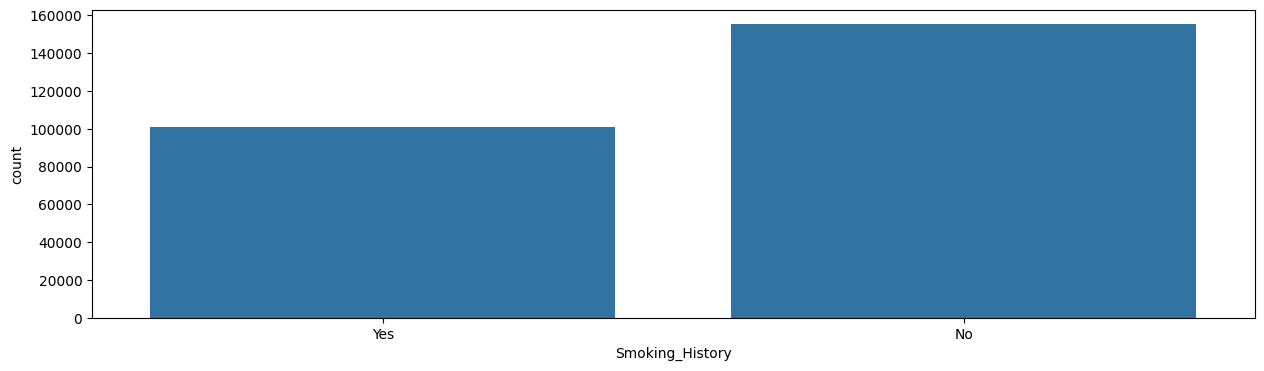

In [32]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df,x="Smoking_History")
plt.show()

In [33]:
Smoking_History_sub=["No","Yes"]
for i in Smoking_History_sub:
  countS = df.loc[df["Smoking_History"]==i] [["Smoking_History"]].count()
  average=(countS*100)//len(df)
  print("Percentage of ",i,average)

Percentage of  No Smoking_History    60
dtype: int64
Percentage of  Yes Smoking_History    39
dtype: int64


ANALIZANDO CADA ENFERMEDAD, SUS CONDICIONES Y FACTORES Y ESTILOS DE VIDA CORRESPONDIENTES

1. Heart Disease Vs Factors

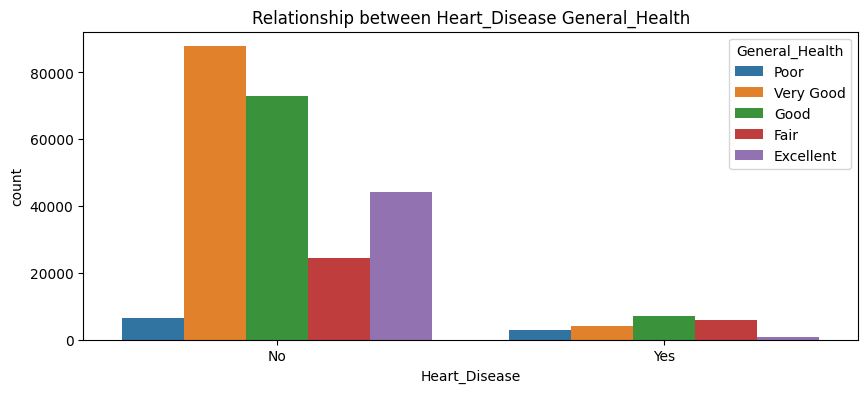

In [34]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Heart_Disease", hue="General_Health")
plt.title("Relationship between Heart_Disease General_Health")
plt.show()

In [35]:
print("Details about reviewers with Heart_Disease, based on General_Health")
print("-"*75)
lst_G=['Poor', 'Very Good', 'Good', 'Fair', 'Excellent']
for i in lst_G:
    data = len(df.loc[(df["General_Health"]==i)])
    data1 = len(df.loc[(df["Heart_Disease"] == "Yes") & (df["General_Health"] == i)])
    percentage = (data1 * 100) // data
    print(percentage, "% of reviewers come under general health ",i," and with heart disorder ")

Details about reviewers with Heart_Disease, based on General_Health
---------------------------------------------------------------------------
31 % of reviewers come under general health  Poor  and with heart disorder 
4 % of reviewers come under general health  Very Good  and with heart disorder 
8 % of reviewers come under general health  Good  and with heart disorder 
19 % of reviewers come under general health  Fair  and with heart disorder 
1 % of reviewers come under general health  Excellent  and with heart disorder 


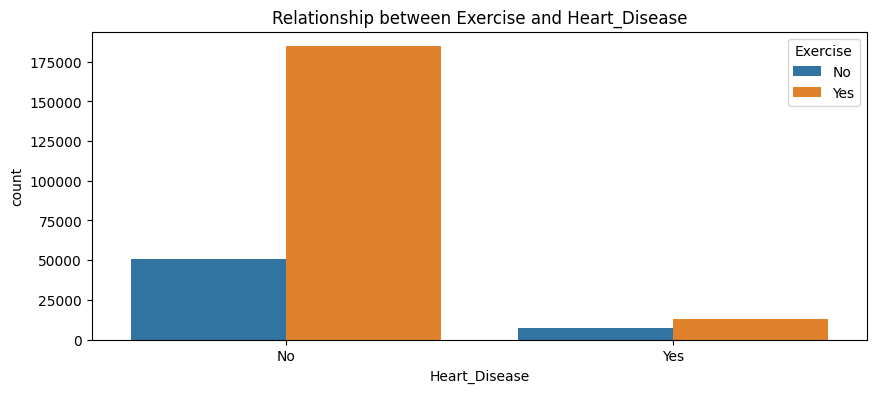

In [36]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Heart_Disease", hue="Exercise")
plt.title("Relationship between Exercise and Heart_Disease")
plt.show()

In [37]:
print("Details about reviewers with Heart_Disease, based on Exercise")
print("-"*75)
lst_E=["Yes","No"]
for i in lst_E:
    datae = len(df.loc[(df["Exercise"]==i)])
    data1e = len(df.loc[(df["Heart_Disease"] == "Yes") & (df["Exercise"] == i)])
    percentage = (data1e * 100) // datae
    print(percentage, "% of reviewers with exercise ",i," and having heart disorder ")

Details about reviewers with Heart_Disease, based on Exercise
---------------------------------------------------------------------------
6 % of reviewers with exercise  Yes  and having heart disorder 
12 % of reviewers with exercise  No  and having heart disorder 


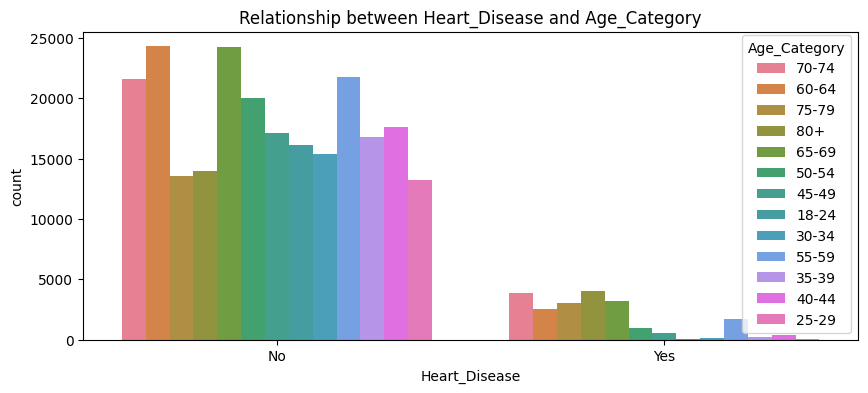

In [38]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Heart_Disease", hue="Age_Category")
plt.title("Relationship between Heart_Disease and Age_Category")
plt.show()

In [39]:
age_cat = df.loc[df["Heart_Disease"]=="Yes"].groupby("Age_Category") ["Heart_Disease"].count().sort_values(ascending=False)
age_cat

Age_Category
80+      4031
70-74    3826
65-69    3199
75-79    3067
60-64    2503
55-59    1670
50-54     970
45-49     557
40-44     349
35-39     223
30-34     161
25-29      79
18-24      66
Name: Heart_Disease, dtype: int64

In [40]:
print("Details about reviewers with Heart_Disease based on Age_Category")
print("-"*75)
lst_A=['70-74', '60-64', '75-79', '80+', '65-69', '50-54', '45-49','18-24', '30-34', '55-59', '35-39', '40-44', '25-29']
for i in lst_A:
    datasc= len(df.loc[(df["Age_Category"]==i)])
    data1sc = len(df[(df["Heart_Disease"] == "Yes") & (df["Age_Category"] == i)])
    percentageoc = (data1sc * 100) // datasc
    print(percentageoc, "%  Age_Category ",i,)

Details about reviewers with Heart_Disease based on Age_Category
---------------------------------------------------------------------------
15 %  Age_Category  70-74
9 %  Age_Category  60-64
18 %  Age_Category  75-79
22 %  Age_Category  80+
11 %  Age_Category  65-69
4 %  Age_Category  50-54
3 %  Age_Category  45-49
0 %  Age_Category  18-24
1 %  Age_Category  30-34
7 %  Age_Category  55-59
1 %  Age_Category  35-39
1 %  Age_Category  40-44
0 %  Age_Category  25-29


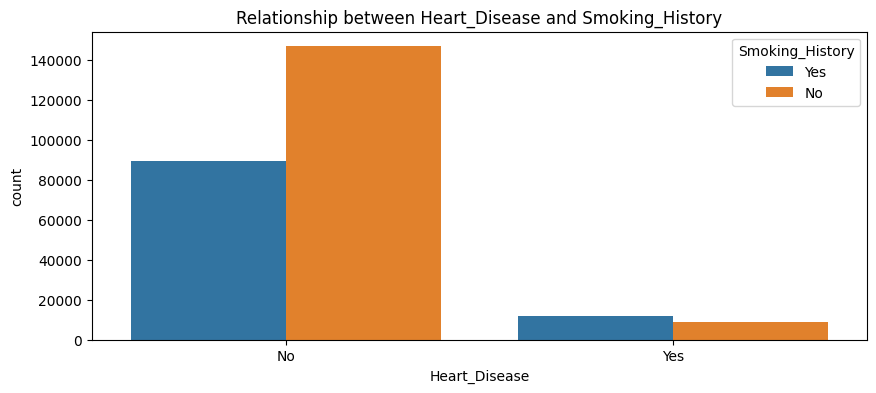

In [41]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Heart_Disease", hue="Smoking_History")
plt.title("Relationship between Heart_Disease and Smoking_History")
plt.show()

In [42]:
print("Details about reviewers with Heart_Disease based on Smoking_History")
print("-"*75)
lst_SH=["Yes","No"]
for i in lst_SH:
    datash = len(df.loc[(df["Smoking_History"]==i)])
    data1sh = len(df.loc[(df["Heart_Disease"] == "Yes") & (df["Exercise"] == i)])
    percentage = (data1sh * 100) // datash
    print(percentage, "% of reviewers with heart disease and Smoking_History ",i)

Details about reviewers with Heart_Disease based on Smoking_History
---------------------------------------------------------------------------
12 % of reviewers with heart disease and Smoking_History  Yes
4 % of reviewers with heart disease and Smoking_History  No


2.Cáncer de piel vs. factores

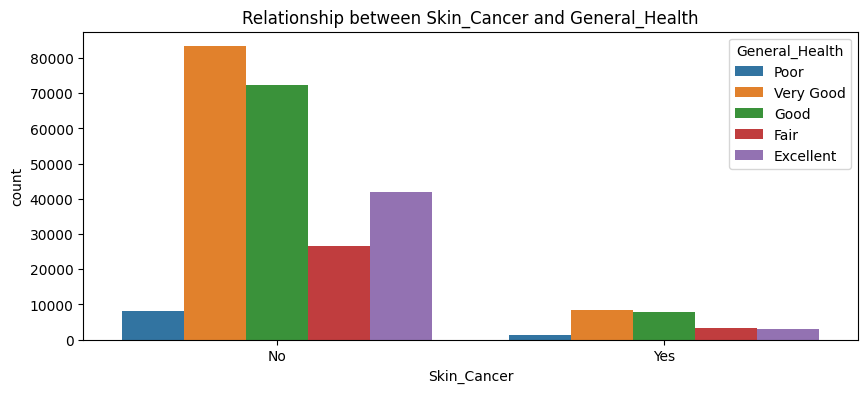

In [43]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Skin_Cancer", hue="General_Health")
plt.title("Relationship between Skin_Cancer and General_Health")
plt.show()

In [44]:
print("Percentage of reviewers with Skin_Cancer based on General Health")
print("-"*75)
lst_G=['Poor', 'Very Good', 'Good', 'Fair', 'Excellent']
for i in lst_G:
    data = len(df.loc[(df["General_Health"]==i)])
    data1sc = len(df.loc[(df["Skin_Cancer"] == "Yes") & (df["General_Health"] == i)])
    percentagesc = (data1sc * 100) // data
    print(percentagesc, "% come under General Health",i,"category")

Percentage of reviewers with Skin_Cancer based on General Health
---------------------------------------------------------------------------
14 % come under General Health Poor category
9 % come under General Health Very Good category
9 % come under General Health Good category
11 % come under General Health Fair category
6 % come under General Health Excellent category


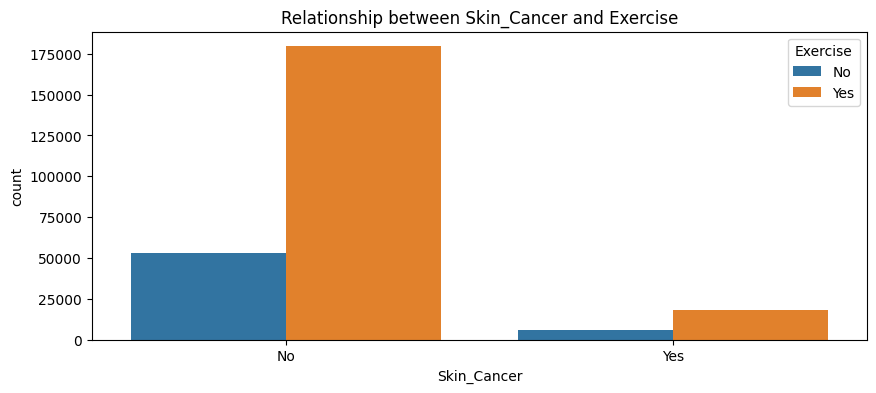

In [45]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Skin_Cancer", hue="Exercise")
plt.title("Relationship between Skin_Cancer and Exercise")
plt.show()

In [46]:
print("Details about reviewers with Skin_Cancer based on Exercise")
print("-"*75)
lst_E=["Yes","No"]
for i in lst_E:
    datasce = len(df.loc[(df["Exercise"]==i)])
    data1sce = len(df.loc[(df["Skin_Cancer"] == "Yes") & (df["Exercise"] == i)])
    percentage = (data1sce * 100) // datasce
    print(percentage, "%  exercise ",i,)

Details about reviewers with Skin_Cancer based on Exercise
---------------------------------------------------------------------------
9 %  exercise  Yes
9 %  exercise  No


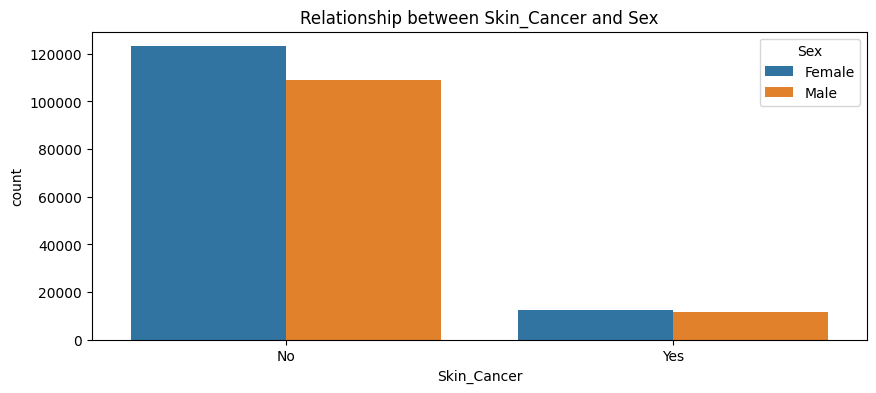

In [47]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Skin_Cancer", hue="Sex")
plt.title("Relationship between Skin_Cancer and Sex")
plt.show()

In [48]:
print("Details about reviewers with Skin_Cancer based on Sex")
print("-"*75)
lst_S=["Male","Female"]
for i in lst_S:
    datasc = len(df.loc[(df["Sex"]==i)])
    data1sc = len(df.loc[(df["Skin_Cancer"] == "Yes") & (df["Sex"] == i)])
    percentages = (data1sc * 100) // datasc
    print(percentages, "% of are ",i)

Details about reviewers with Skin_Cancer based on Sex
---------------------------------------------------------------------------
9 % of are  Male
9 % of are  Female


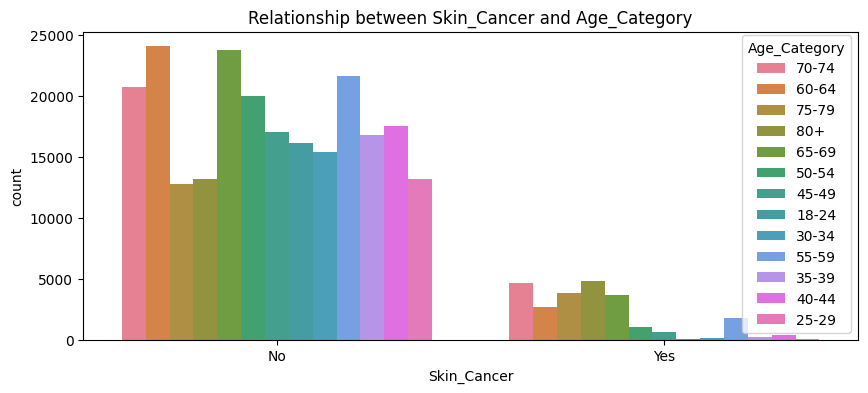

In [49]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Skin_Cancer", hue="Age_Category")
plt.title("Relationship between Skin_Cancer and Age_Category")
plt.show()

In [50]:
age_cats = df.loc[df["Skin_Cancer"]=="Yes"].groupby("Age_Category") ["Skin_Cancer"].count().sort_values(ascending=False)
age_cats

Age_Category
80+      4837
70-74    4683
75-79    3856
65-69    3664
60-64    2707
55-59    1789
50-54    1026
45-49     600
40-44     412
35-39     230
30-34     112
25-29      74
18-24      43
Name: Skin_Cancer, dtype: int64

In [51]:
print("Details about reviewers with Skin_Cancer based on Age_Category")
print("-"*75)
lst_A=['70-74', '60-64', '75-79', '80+', '65-69', '50-54', '45-49','18-24', '30-34', '55-59', '35-39', '40-44', '25-29']
for i in lst_A:
    datasc= len(df.loc[(df["Age_Category"]==i)])
    data1sc = len(df.loc[(df["Skin_Cancer"] == "Yes") & (df["Age_Category"] == i)])
    percentageoc = (data1sc * 100) // datasc
    print(percentageoc, "%  Age_Category ",i,)

Details about reviewers with Skin_Cancer based on Age_Category
---------------------------------------------------------------------------
18 %  Age_Category  70-74
10 %  Age_Category  60-64
23 %  Age_Category  75-79
26 %  Age_Category  80+
13 %  Age_Category  65-69
4 %  Age_Category  50-54
3 %  Age_Category  45-49
0 %  Age_Category  18-24
0 %  Age_Category  30-34
7 %  Age_Category  55-59
1 %  Age_Category  35-39
2 %  Age_Category  40-44
0 %  Age_Category  25-29


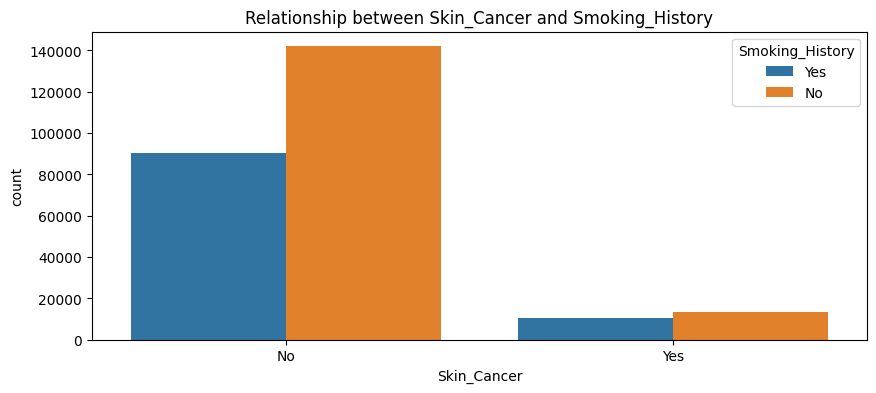

In [52]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Skin_Cancer", hue="Smoking_History")
plt.title("Relationship between Skin_Cancer and Smoking_History")
plt.show()

In [53]:
print("Details about reviewers with Skin_Cancer based on Smoking_History")
print("-"*75)
lst_SH=["Yes","No"]
for i in lst_SH:
    datash = len(df.loc[(df["Smoking_History"]==i)])
    data1sh = len(df.loc[(df["Skin_Cancer"] == "Yes") & (df["Smoking_History"] == i)])
    percentage = (data1sh * 100) // datash
    print(percentage, "% of reviewers with heart disease and Smoking_History ",i)

Details about reviewers with Skin_Cancer based on Smoking_History
---------------------------------------------------------------------------
10 % of reviewers with heart disease and Smoking_History  Yes
8 % of reviewers with heart disease and Smoking_History  No


3.Otros_Cáncer Vs variables

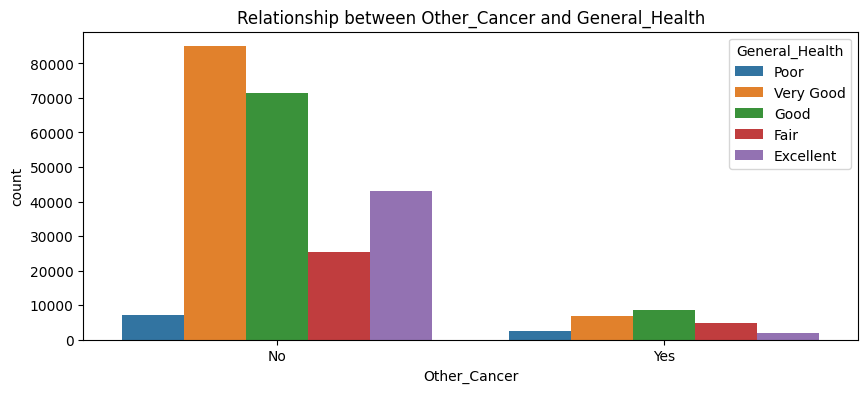

In [54]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Other_Cancer", hue="General_Health")
plt.title("Relationship between Other_Cancer and General_Health")
plt.show()

In [55]:
print("Percentage of reviewers with Skin_Cancer based on General Health")
print("-"*75)
lst_G=['Poor', 'Very Good', 'Good', 'Fair', 'Excellent']
for i in lst_G:
    data = len(df.loc[(df["General_Health"]==i)])
    data1sc = len(df.loc[(df["Other_Cancer"] == "Yes") & (df["General_Health"] == i)])
    percentagesc = (data1sc * 100) // data
    print(percentagesc, "% come under General Health",i,"category")

Percentage of reviewers with Skin_Cancer based on General Health
---------------------------------------------------------------------------
25 % come under General Health Poor category
7 % come under General Health Very Good category
10 % come under General Health Good category
15 % come under General Health Fair category
4 % come under General Health Excellent category


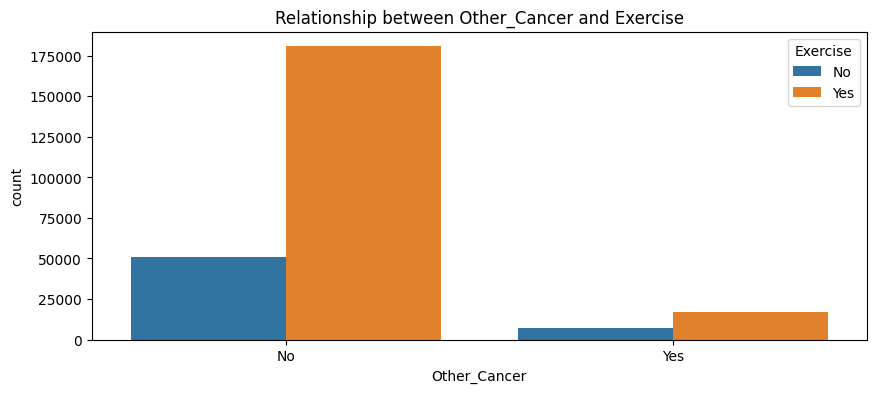

In [56]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Other_Cancer", hue="Exercise")
plt.title("Relationship between Other_Cancer and Exercise")
plt.show()

In [57]:
print("Details about reviewers with Other_Cancer based on Exercise")
print("-"*75)
lst_E=["Yes","No"]
for i in lst_E:
    datasce = len(df.loc[(df["Exercise"]==i)])
    data1sce = len(df.loc[(df["Other_Cancer"] == "Yes") & (df["Exercise"] == i)])
    percentage = (data1sce * 100) // datasce
    print(percentage, "%  exercise ",i,)

Details about reviewers with Other_Cancer based on Exercise
---------------------------------------------------------------------------
8 %  exercise  Yes
12 %  exercise  No


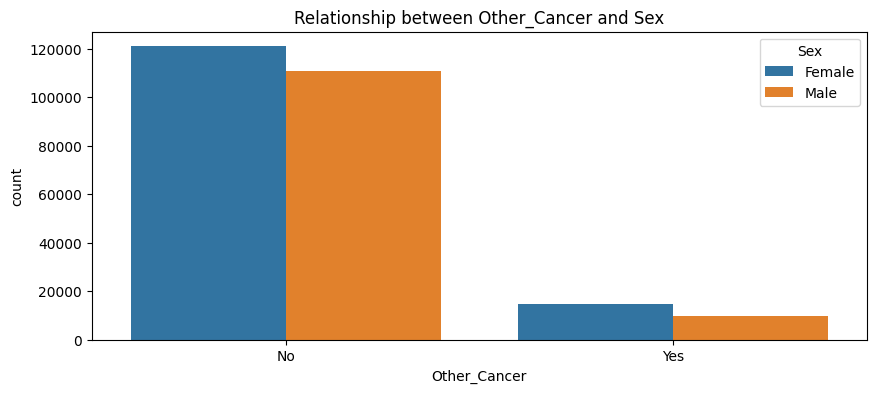

In [58]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Other_Cancer", hue="Sex")
plt.title("Relationship between Other_Cancer and Sex")
plt.show()

In [59]:
print("Details about reviewers with Other_Cancer based on Sex")
print("-"*75)
lst_S=["Male","Female"]
for i in lst_S:
    dataoc= len(df.loc[(df["Sex"]==i)])
    data1oc = len(df.loc[(df["Other_Cancer"] == "Yes") & (df["Sex"] == i)])
    percentageoc = (data1oc * 100) // dataoc
    print(percentageoc, "%  sex ",i,)

Details about reviewers with Other_Cancer based on Sex
---------------------------------------------------------------------------
8 %  sex  Male
10 %  sex  Female


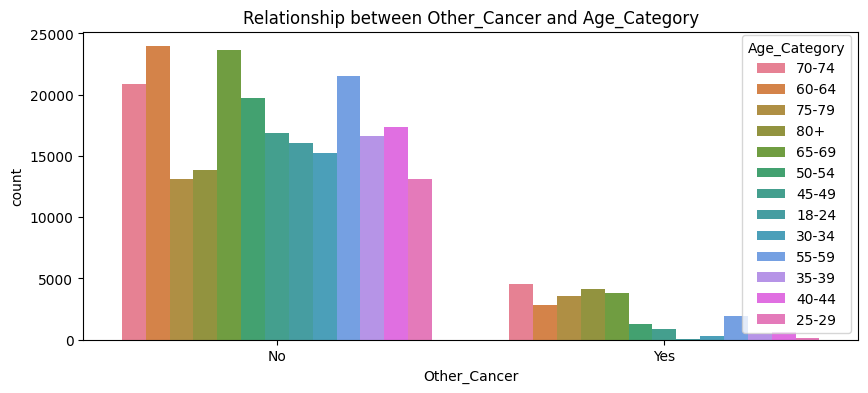

In [60]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Other_Cancer", hue="Age_Category")
plt.title("Relationship between Other_Cancer and Age_Category")
plt.show()

In [61]:
age_cato = df.loc[df["Other_Cancer"]=="Yes"].groupby("Age_Category") ["Other_Cancer"].count().sort_values(ascending=False)
age_cato

Age_Category
70-74    4565
80+      4166
65-69    3832
75-79    3517
60-64    2862
55-59    1920
50-54    1281
45-49     826
40-44     609
35-39     435
30-34     280
25-29     138
18-24      85
Name: Other_Cancer, dtype: int64

In [62]:
print("Details about reviewers with Other_Cancer based on Age_Category")
print("-"*75)
lst_A=['70-74', '60-64', '75-79', '80+', '65-69', '50-54', '45-49','18-24', '30-34', '55-59', '35-39', '40-44', '25-29']
for i in lst_A:
    dataoc= len(df.loc[(df["Age_Category"]==i)])
    data1oc = len(df.loc[(df["Other_Cancer"] == "Yes") & (df["Age_Category"] == i)])
    percentageoc = (data1oc * 100) // dataoc
    print(percentageoc, "%  Age_Category ",i,)

Details about reviewers with Other_Cancer based on Age_Category
---------------------------------------------------------------------------
17 %  Age_Category  70-74
10 %  Age_Category  60-64
21 %  Age_Category  75-79
23 %  Age_Category  80+
13 %  Age_Category  65-69
6 %  Age_Category  50-54
4 %  Age_Category  45-49
0 %  Age_Category  18-24
1 %  Age_Category  30-34
8 %  Age_Category  55-59
2 %  Age_Category  35-39
3 %  Age_Category  40-44
1 %  Age_Category  25-29


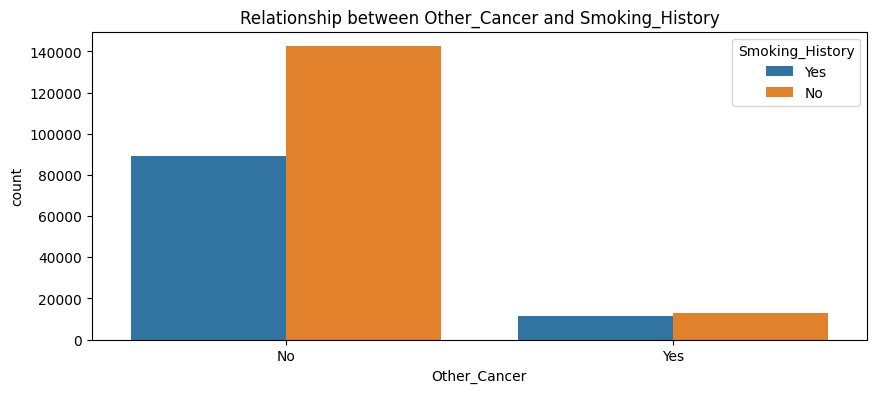

In [63]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Other_Cancer", hue="Smoking_History")
plt.title("Relationship between Other_Cancer and Smoking_History")
plt.show()

In [64]:
print("Details about reviewers with Other_Cancer based on Smoking_History")
print("-"*75)
lst_S=["Yes","No"]
for i in lst_S:
    dataoc= len(df.loc[(df["Smoking_History"]==i)])
    data1oc = len(df.loc[(df["Other_Cancer"] == "Yes") & (df["Smoking_History"] == i)])
    percentageoc = (data1oc * 100) // dataoc
    print(percentageoc, "%  Smoking_History ",i)

Details about reviewers with Other_Cancer based on Smoking_History
---------------------------------------------------------------------------
11 %  Smoking_History  Yes
8 %  Smoking_History  No


4.Diabetes vs. Variables

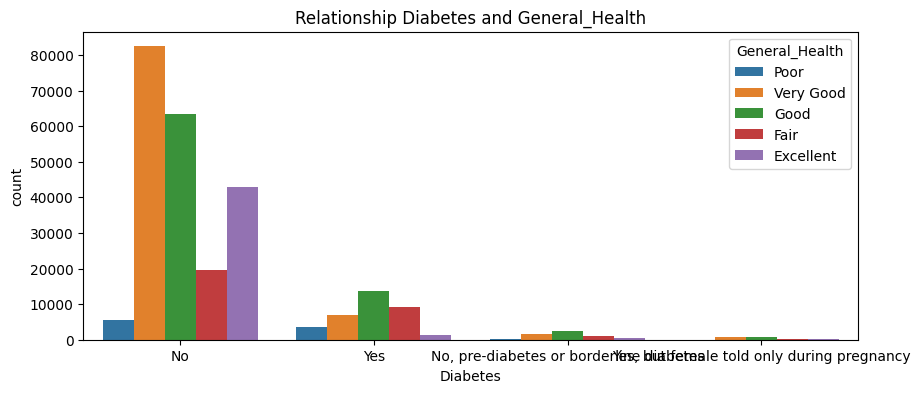

In [65]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Diabetes", hue="General_Health")
plt.title("Relationship Diabetes and General_Health")
plt.show()

In [66]:
print("Details about reviewers with Diabetes based on General_Health")
print("-"*75)
lst_G=['Poor', 'Very Good', 'Good', 'Fair', 'Excellent']
for i in lst_G:
    datadg= len(df.loc[(df["General_Health"]==i)])
    data1dg = len(df.loc[(df["Diabetes"] == "Yes") & (df["General_Health"] == i)])
    percentdg = (data1dg * 100) // datadg
    print(percentdg, "%  General_Health ",i)

Details about reviewers with Diabetes based on General_Health
---------------------------------------------------------------------------
37 %  General_Health  Poor
7 %  General_Health  Very Good
16 %  General_Health  Good
30 %  General_Health  Fair
2 %  General_Health  Excellent


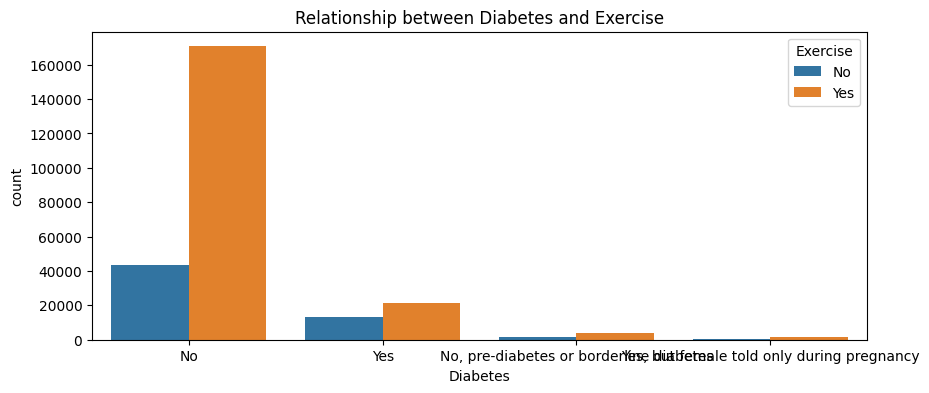

In [67]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Diabetes", hue="Exercise")
plt.title("Relationship between Diabetes and Exercise")
plt.show()

In [68]:
print("Details about reviewers with Diabetes based on Exercise")
print("-"*75)
lst_G=["Yes","No"]
for i in lst_G:
    datadg= len(df.loc[(df["Exercise"]==i)])
    data1dg = len(df[(df["Diabetes"] == "Yes") & (df["Exercise"] == i)])
    percentdg = (data1dg * 100) // datadg
    print(percentdg, "%  Exercise ",i)

Details about reviewers with Diabetes based on Exercise
---------------------------------------------------------------------------
10 %  Exercise  Yes
22 %  Exercise  No


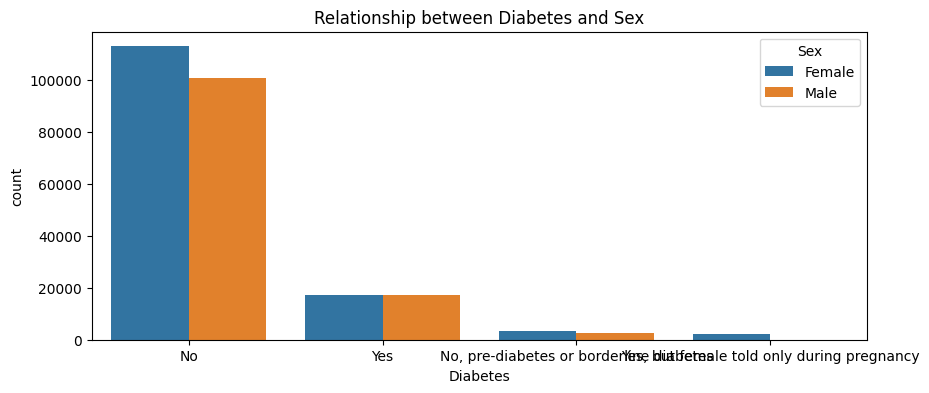

In [69]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Diabetes", hue="Sex")
plt.title("Relationship between Diabetes and Sex")
plt.show()

In [70]:
print("Details about reviewers with Diabetes based on Sex")
print("-"*75)
lst_S=["Male","Female"]
for i in lst_S:
    datadg= len(df.loc[(df["Sex"]==i)])
    data1dg = len(df[(df["Diabetes"] == "Yes") & (df["Sex"] == i)])
    percentdg = (data1dg * 100) // datadg
    print(percentdg, "%  Sex ",i)

Details about reviewers with Diabetes based on Sex
---------------------------------------------------------------------------
14 %  Sex  Male
12 %  Sex  Female


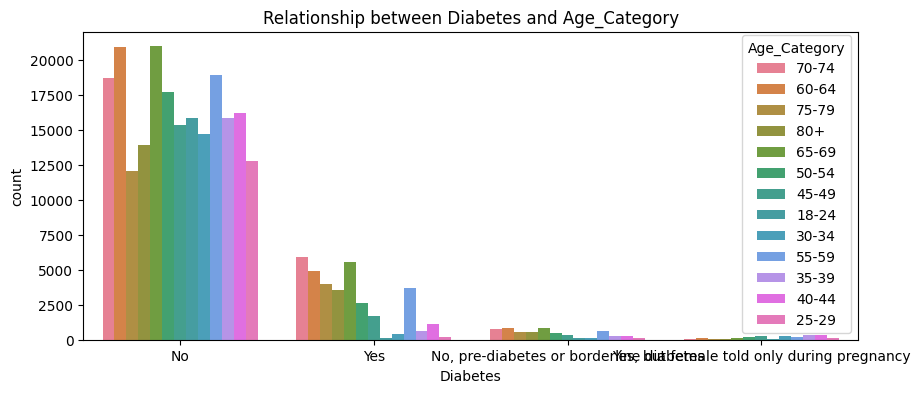

In [71]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Diabetes", hue="Age_Category")
plt.title("Relationship between Diabetes and Age_Category")
plt.show()

In [72]:
age_cato1 = df.loc[df["Diabetes"]=="Yes"].groupby("Age_Category") ["Diabetes"].count().sort_values(ascending=False)
age_cato1

Age_Category
70-74    5883
65-69    5550
60-64    4922
75-79    3961
55-59    3725
80+      3535
50-54    2604
45-49    1700
40-44    1102
35-39     638
30-34     381
25-29     223
18-24     148
Name: Diabetes, dtype: int64

In [73]:
print("Details about reviewers with Diabetes based on Age_Category")
print("-"*75)
lst_A=['70-74', '60-64', '75-79', '80+', '65-69', '50-54', '45-49','18-24', '30-34', '55-59', '35-39', '40-44', '25-29']
for i in lst_A:
    dataoc= len(df.loc[(df["Age_Category"]==i)])
    data1oc = len(df[(df["Diabetes"] == "Yes") & (df["Age_Category"] == i)])
    percentageoc = (data1oc * 100) // dataoc
    print(percentageoc, "%  Age_Category ",i,)

Details about reviewers with Diabetes based on Age_Category
---------------------------------------------------------------------------
23 %  Age_Category  70-74
18 %  Age_Category  60-64
23 %  Age_Category  75-79
19 %  Age_Category  80+
20 %  Age_Category  65-69
12 %  Age_Category  50-54
9 %  Age_Category  45-49
0 %  Age_Category  18-24
2 %  Age_Category  30-34
15 %  Age_Category  55-59
3 %  Age_Category  35-39
6 %  Age_Category  40-44
1 %  Age_Category  25-29


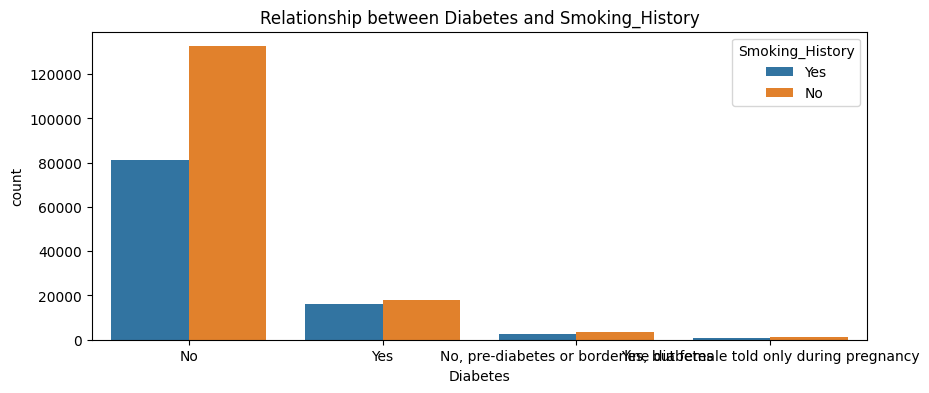

In [74]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Diabetes", hue="Smoking_History")
plt.title("Relationship between Diabetes and Smoking_History")
plt.show()

In [75]:
print("Details about reviewers with Diabetes based on Smoking_History")
print("-"*75)
lst_S=["Yes","No"]
for i in lst_S:
    datadg= len(df.loc[(df["Smoking_History"]==i)])
    data1dg = len(df[(df["Diabetes"] == "Yes") & (df["Smoking_History"] == i)])
    percentdg = (data1dg * 100) // datadg
    print(percentdg, "%  Smoking_History ",i)

Details about reviewers with Diabetes based on Smoking_History
---------------------------------------------------------------------------
16 %  Smoking_History  Yes
11 %  Smoking_History  No


5.Arthritis Vs Variables

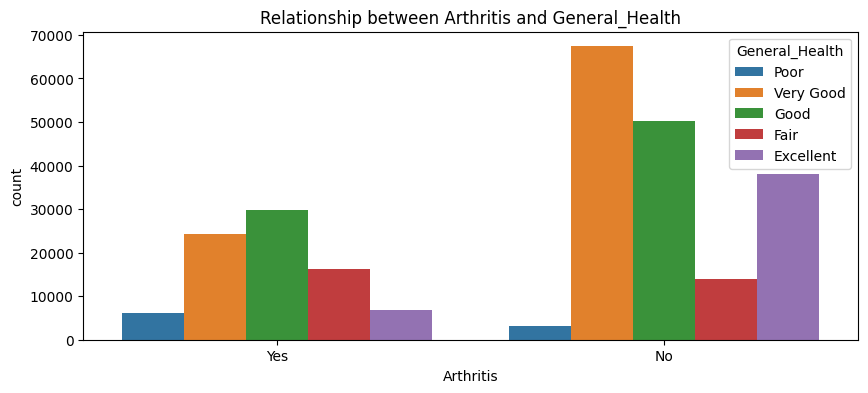

In [76]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Arthritis", hue="General_Health")
plt.title("Relationship between Arthritis and General_Health")
plt.show()

In [77]:
print("Details about reviewers with Arthritis based on General_Health")
print("-"*75)
lst_G=['Poor', 'Very Good', 'Good', 'Fair', 'Excellent']
for i in lst_G:
    data= len(df.loc[(df["General_Health"]==i)])
    data1 = len(df[(df["Arthritis"] == "Yes") & (df["General_Health"] == i)])
    percentage = (data1 * 100) // data
    print(percentage, "%  General_Health ",i)

Details about reviewers with Arthritis based on General_Health
---------------------------------------------------------------------------
65 %  General_Health  Poor
26 %  General_Health  Very Good
37 %  General_Health  Good
53 %  General_Health  Fair
15 %  General_Health  Excellent


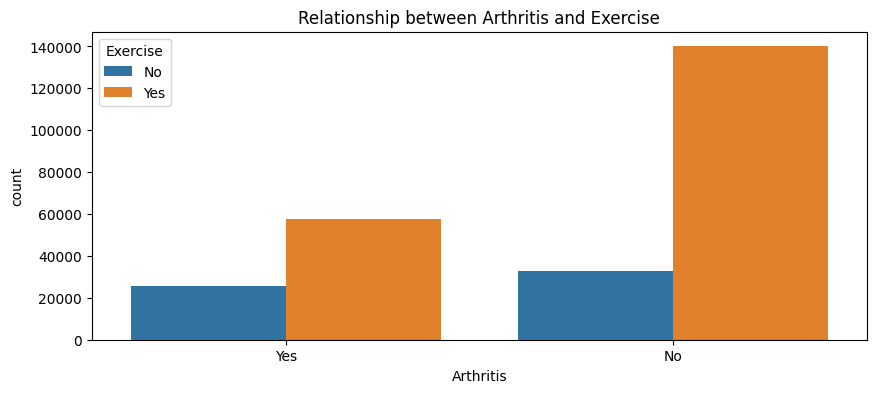

In [78]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Arthritis", hue="Exercise")
plt.title("Relationship between Arthritis and Exercise")
plt.show()

In [79]:
print("Details about reviewers with Arthritis based on Exercise")
print("-"*75)
lst_A=["Yes","No"]
for i in lst_A:
    data= len(df.loc[(df["Exercise"]==i)])
    data1 = len(df[(df["Arthritis"] == "Yes") & (df["Exercise"] == i)])
    percentage = (data1 * 100) // data
    print(percentage, "%  Exercise ",i)

Details about reviewers with Arthritis based on Exercise
---------------------------------------------------------------------------
29 %  Exercise  Yes
43 %  Exercise  No


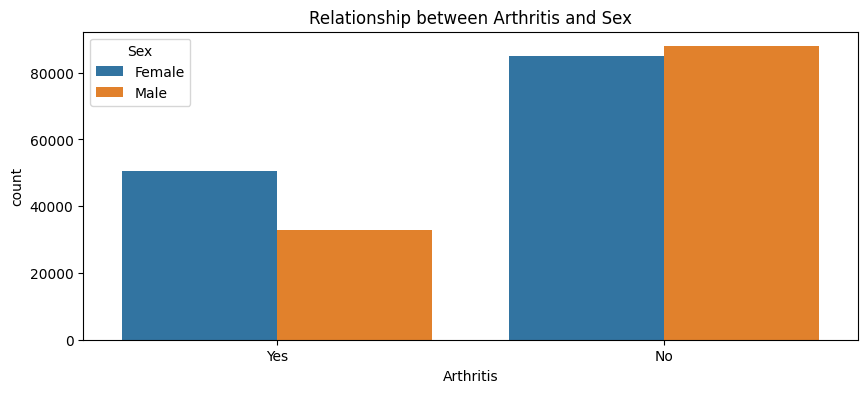

In [80]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Arthritis", hue="Sex")
plt.title("Relationship between Arthritis and Sex")
plt.show()

In [81]:
print("Details about reviewers with Arthritis based on Sex")
print("-"*75)
lst_E=["Male","Female"]
for i in lst_E:
    data= len(df.loc[(df["Sex"]==i)])
    data1 = len(df[(df["Arthritis"] == "Yes") & (df["Sex"] == i)])
    percentage = (data1 * 100) // data
    print(percentage, "%  Sex ",i)

Details about reviewers with Arthritis based on Sex
---------------------------------------------------------------------------
27 %  Sex  Male
37 %  Sex  Female


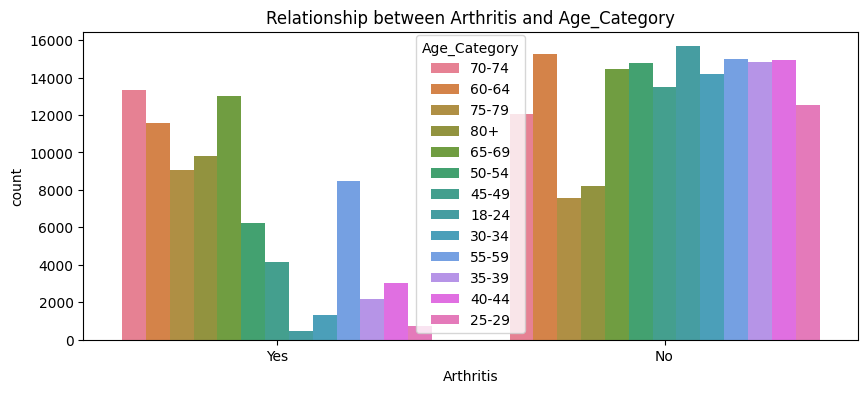

In [82]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Arthritis", hue="Age_Category")
plt.title("Relationship between Arthritis and Age_Category")
plt.show()

In [83]:
age_cato4 = df.loc[df["Diabetes"]=="Yes"].groupby("Age_Category") ["Diabetes"].count().sort_values(ascending=False)
age_cato4

Age_Category
70-74    5883
65-69    5550
60-64    4922
75-79    3961
55-59    3725
80+      3535
50-54    2604
45-49    1700
40-44    1102
35-39     638
30-34     381
25-29     223
18-24     148
Name: Diabetes, dtype: int64

In [84]:
print("Details about reviewers with Arthritis based on Age_Category")
print("-"*75)
lst_A=['70-74', '60-64', '75-79', '80+', '65-69', '50-54', '45-49','18-24', '30-34', '55-59', '35-39', '40-44', '25-29']
for i in lst_A:
    data= len(df.loc[(df["Age_Category"]==i)])
    data1 = len(df[(df["Arthritis"] == "Yes") & (df["Age_Category"] == i)])
    percentageoc = (data1oc * 100) // dataoc
    print(percentageoc, "%  Age_Category ",i,)

Details about reviewers with Arthritis based on Age_Category
---------------------------------------------------------------------------
1 %  Age_Category  70-74
1 %  Age_Category  60-64
1 %  Age_Category  75-79
1 %  Age_Category  80+
1 %  Age_Category  65-69
1 %  Age_Category  50-54
1 %  Age_Category  45-49
1 %  Age_Category  18-24
1 %  Age_Category  30-34
1 %  Age_Category  55-59
1 %  Age_Category  35-39
1 %  Age_Category  40-44
1 %  Age_Category  25-29


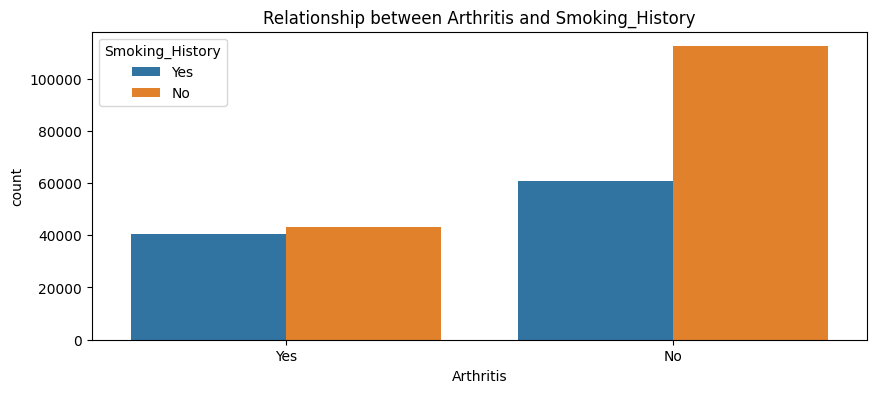

In [85]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Arthritis", hue="Smoking_History")
plt.title("Relationship between Arthritis and Smoking_History")
plt.show()

In [86]:
print("Details about reviewers with Arthritis based on Smoking_History")
print("-"*75)
lst_E=["Yes","No"]
for i in lst_E:
    data= len(df.loc[(df["Smoking_History"]==i)])
    data1 = len(df[(df["Arthritis"] == "Yes") & (df["Smoking_History"] == i)])
    percentage = (data1 * 100) // data
    print(percentage, "%  Smoking_History ",i)

Details about reviewers with Arthritis based on Smoking_History
---------------------------------------------------------------------------
39 %  Smoking_History  Yes
27 %  Smoking_History  No


6. Depresión vs. Variables

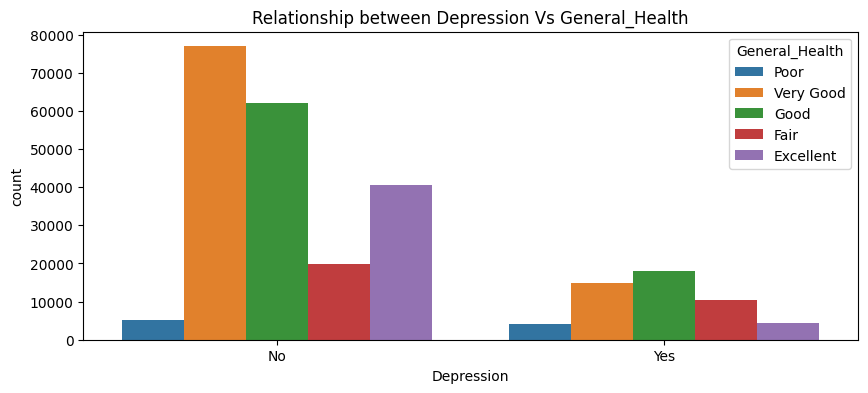

In [87]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Depression", hue="General_Health")
plt.title("Relationship between Depression Vs General_Health")
plt.show()

In [88]:
print("Details about reviewers with Depression, based on General_Health")
print("-"*75)
lst_G=['Poor', 'Very Good', 'Good', 'Fair', 'Excellent']
for i in lst_G:
    dataad = len(df.loc[(df["General_Health"]==i)])
    dataad1 = len(df.loc[(df["Depression"] == "Yes") & (df["General_Health"] == i)])
    percentage = (dataad1 * 100) // dataad
    print(percentage, "% of reviewers come under general health ",i," and with Depression ")

Details about reviewers with Depression, based on General_Health
---------------------------------------------------------------------------
44 % of reviewers come under general health  Poor  and with Depression 
16 % of reviewers come under general health  Very Good  and with Depression 
22 % of reviewers come under general health  Good  and with Depression 
34 % of reviewers come under general health  Fair  and with Depression 
9 % of reviewers come under general health  Excellent  and with Depression 


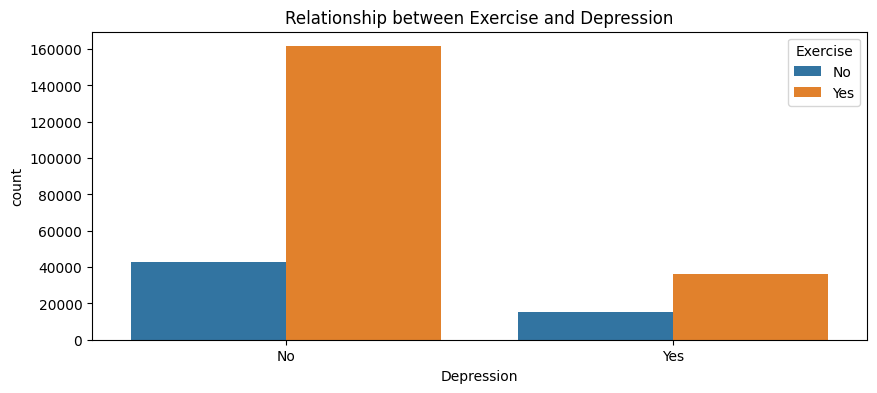

In [89]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Depression", hue="Exercise")
plt.title("Relationship between Exercise and Depression")
plt.show()

In [90]:
print("Details about reviewers with Depression, based on Exercise")
print("-"*75)
lst_E=["Yes","No"]
for i in lst_E:
    dataad = len(df.loc[(df["Exercise"]==i)])
    data1ad = len(df.loc[(df["Depression"] == "Yes") & (df["Exercise"] == i)])
    percentage = (data1ad * 100) // dataad
    print(percentage, "% of reviewers with exercise ",i," and having Depression ")

Details about reviewers with Depression, based on Exercise
---------------------------------------------------------------------------
18 % of reviewers with exercise  Yes  and having Depression 
26 % of reviewers with exercise  No  and having Depression 


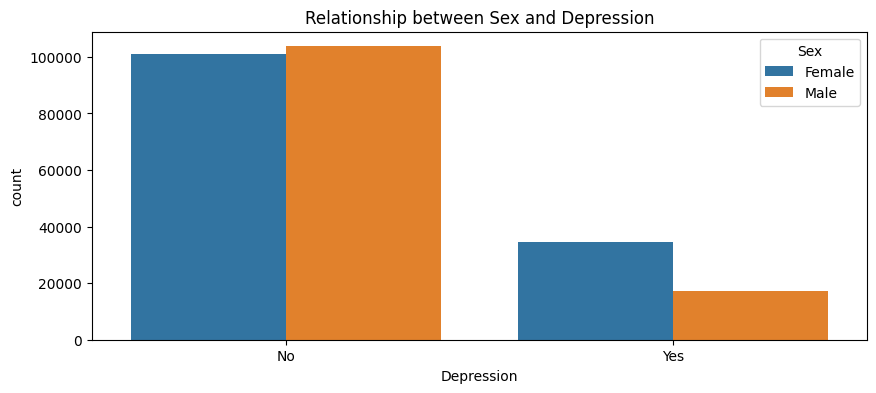

In [91]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Depression", hue="Sex")
plt.title("Relationship between Sex and Depression")
plt.show()

In [92]:
print("Details about reviewers with Depression, based on Sex")
print("-"*75)
lst_S=["Male","Female"]
for i in lst_S:
    datas = len(df.loc[(df["Sex"]==i)])
    data1s = len(df.loc[(df["Depression"] == "Yes") & (df["Sex"] == i)])
    percentages = (data1s * 100) // datas
    print(percentages, "% of reviewers with Depression come under Sex ",i)

Details about reviewers with Depression, based on Sex
---------------------------------------------------------------------------
14 % of reviewers with Depression come under Sex  Male
25 % of reviewers with Depression come under Sex  Female


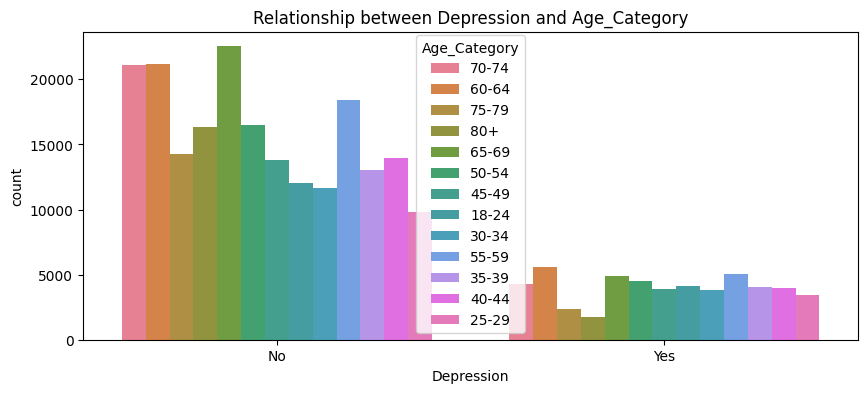

In [95]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Depression", hue="Age_Category")
plt.title("Relationship between Depression and Age_Category")
plt.show()

In [96]:
age_catd = df.loc[df["Depression"]=="Yes"].groupby("Age_Category") ["Depression"].count().sort_values(ascending=False)
age_catd

Age_Category
60-64    5591
55-59    5024
65-69    4907
50-54    4545
70-74    4313
18-24    4140
35-39    4032
40-44    3990
45-49    3872
30-34    3825
25-29    3473
75-79    2344
80+      1716
Name: Depression, dtype: int64

In [97]:
print("Details about reviewers with Depression based on Age_Category")
print("-"*75)
lst_A=['70-74', '60-64', '75-79', '80+', '65-69', '50-54', '45-49','18-24', '30-34', '55-59', '35-39', '40-44', '25-29']
for i in lst_A:
    datas_d= len(df.loc[(df["Age_Category"]==i)])
    data1s_d = len(df[(df["Depression"] == "Yes") & (df["Age_Category"] == i)])
    percentageoc = (data1s_d * 100) // datas_d
    print(percentageoc, "%  Age_Category ",i,)

Details about reviewers with Depression based on Age_Category
---------------------------------------------------------------------------
16 %  Age_Category  70-74
20 %  Age_Category  60-64
14 %  Age_Category  75-79
9 %  Age_Category  80+
17 %  Age_Category  65-69
21 %  Age_Category  50-54
21 %  Age_Category  45-49
25 %  Age_Category  18-24
24 %  Age_Category  30-34
21 %  Age_Category  55-59
23 %  Age_Category  35-39
22 %  Age_Category  40-44
26 %  Age_Category  25-29


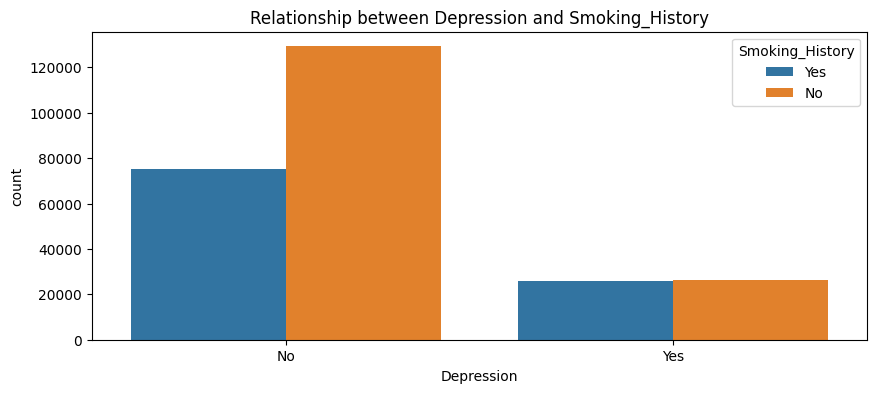

In [98]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Depression", hue="Smoking_History")
plt.title("Relationship between Depression and Smoking_History")
plt.show()

In [99]:
print("Details about reviewers with Depression based on Smoking_History")
print("-"*75)
lst_SH=["Yes","No"]
for i in lst_SH:
    datash = len(df.loc[(df["Smoking_History"]==i)])
    data1sh = len(df.loc[(df["Depression"] == "Yes") & (df["Exercise"] == i)])
    percentage = (data1sh * 100) // datash
    print(percentage, "% of reviewers with Depression and Smoking_History ",i)

Details about reviewers with Depression based on Smoking_History
---------------------------------------------------------------------------
35 % of reviewers with Depression and Smoking_History  Yes
9 % of reviewers with Depression and Smoking_History  No


In [100]:
any_1 = df.loc[(df["Heart_Disease"]=="Yes")|(df["Skin_Cancer"]=="Yes")|(df["Other_Cancer"]=="Yes")|(df["Depression"]=="Yes")|(df["Diabetes"]=="Yes")|(df["Arthritis"]=="Yes")]

<Axes: xlabel='Heart_Disease', ylabel='count'>

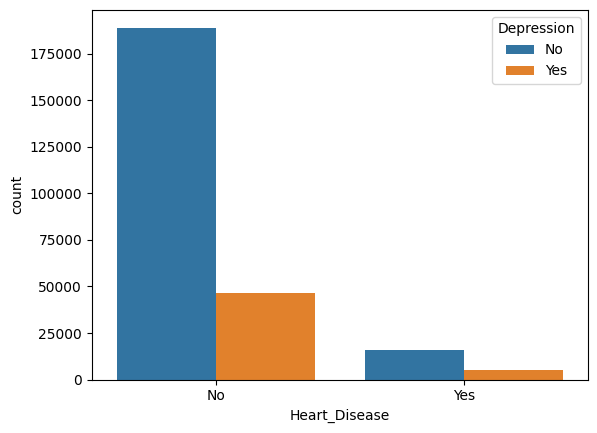

In [101]:
sns.countplot(x='Heart_Disease', hue='Depression', data=df)

In [102]:
h_d = df.loc[(df["Heart_Disease"]=="Yes")&(df["Depression"]=="Yes")]
len(h_d)

5073

In [103]:
h = df.loc[df["Heart_Disease"]=="Yes"]
print(len(h))

20701


In [104]:
pe =print("percentge of heart_disorder due to depression",len(h_d)*100//len(h))

percentge of heart_disorder due to depression 24


<Axes: xlabel='Arthritis', ylabel='count'>

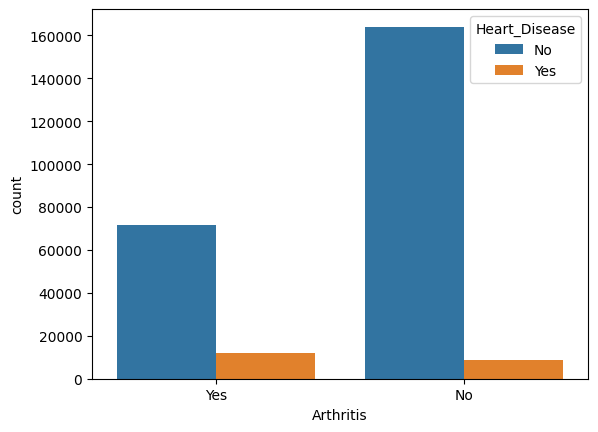

In [105]:
sns.countplot(x='Arthritis', hue='Heart_Disease', data=df)

In [106]:
c_a = df.loc[(df["Heart_Disease"]=="Yes")&(df["Arthritis"])]
len(c_a)

20701

In [107]:
pec =print("percentge of heart_disorder due to arthritis",len(c_a)*100//len(h))

percentge of heart_disorder due to arthritis 100


<Axes: xlabel='Skin_Cancer', ylabel='count'>

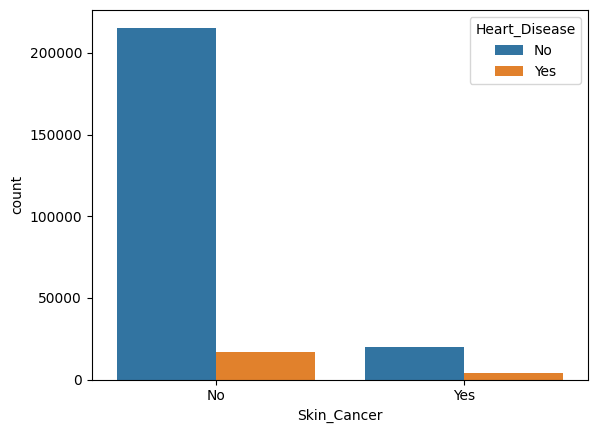

In [108]:
sns.countplot(x='Skin_Cancer', hue='Heart_Disease', data=df)

<Axes: xlabel='Other_Cancer', ylabel='count'>

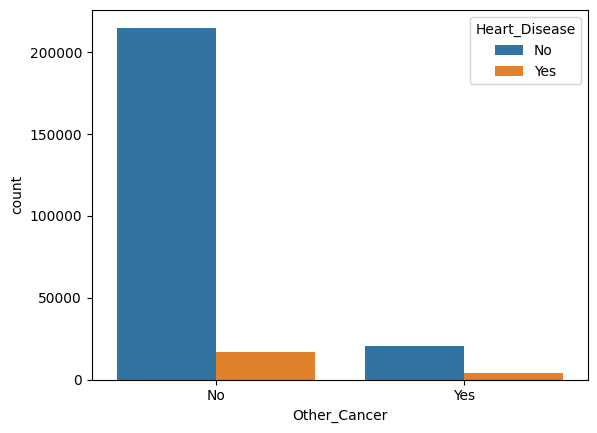

In [109]:
sns.countplot(x='Other_Cancer', hue='Heart_Disease', data=df)

<Axes: xlabel='Diabetes', ylabel='count'>

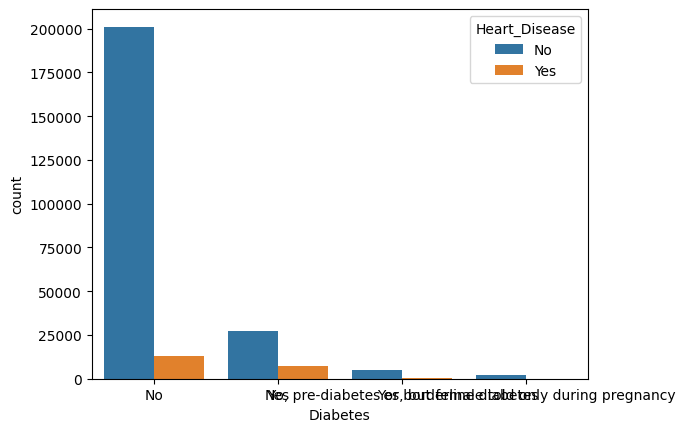

In [110]:
sns.countplot(x='Diabetes', hue='Heart_Disease', data=df)
    

In [111]:
D_H = df.loc[(df["Heart_Disease"]=="Yes")&(df["Diabetes"])]
len(D_H)

20701

In [112]:
df["Age_Category"].unique()

array(['70-74', '60-64', '75-79', '80+', '65-69', '50-54', '45-49',
       '18-24', '30-34', '55-59', '35-39', '40-44', '25-29'], dtype=object)

In [113]:
df["Age_Category"].replace(['80+','75-79','70-74','65-69','60-64','55-59', '50-54', '45-49','40-44','35-39','30-34', '25-29','18-24'], [12,11,10,9,8,7,6,5,4,3,2,1,0],inplace=True)

In [114]:
df.columns.unique()

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History',
       'Alcohol_Consumption', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'FriedPotato_Consumption'],
      dtype='object')